<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/03_deep_learning/optimization_regularization/experiment_neural_network_regularization_dropout_weight_decay_batchnorm_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# LEVEL 1: BASE MODEL (OVERFITTING)
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim

# Fake data
X = torch.randn(500, 20)
y = (X.sum(dim=1) > 0).long()

# Model
model = nn.Sequential(
    nn.Linear(20, 128),
    nn.ReLU(),
    nn.Linear(128, 2)
)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

loss_history_base = []

for epoch in range(50):
    optimizer.zero_grad()

    output = model(X)
    loss = loss_fn(output, y)

    loss.backward()
    optimizer.step()

    loss_history_base.append(loss.item())

print("Base model trained")

Base model trained


In [2]:
# ============================================
# LEVEL 2: DROPOUT
# ============================================

model_dropout = nn.Sequential(
    nn.Linear(20, 128),
    nn.ReLU(),
    nn.Dropout(0.5),   # 🔥 key
    nn.Linear(128, 2)
)

optimizer = optim.Adam(model_dropout.parameters())

loss_history_dropout = []

for epoch in range(50):
    optimizer.zero_grad()

    output = model_dropout(X)
    loss = loss_fn(output, y)

    loss.backward()
    optimizer.step()

    loss_history_dropout.append(loss.item())

print("Dropout model trained")

Dropout model trained


In [3]:
# ============================================
# LEVEL 3: WEIGHT DECAY
# ============================================

model_wd = nn.Sequential(
    nn.Linear(20, 128),
    nn.ReLU(),
    nn.Linear(128, 2)
)

optimizer = optim.Adam(model_wd.parameters(), weight_decay=0.01)

loss_history_wd = []

for epoch in range(50):
    optimizer.zero_grad()

    output = model_wd(X)
    loss = loss_fn(output, y)

    loss.backward()
    optimizer.step()

    loss_history_wd.append(loss.item())

print("Weight decay model trained")

Weight decay model trained


In [4]:
# ============================================
# LEVEL 4: BATCH NORM
# ============================================

model_bn = nn.Sequential(
    nn.Linear(20, 128),
    nn.BatchNorm1d(128),  # 🔥 key
    nn.ReLU(),
    nn.Linear(128, 2)
)

optimizer = optim.Adam(model_bn.parameters())

loss_history_bn = []

for epoch in range(50):
    optimizer.zero_grad()

    output = model_bn(X)
    loss = loss_fn(output, y)

    loss.backward()
    optimizer.step()

    loss_history_bn.append(loss.item())

print("BatchNorm model trained")

BatchNorm model trained


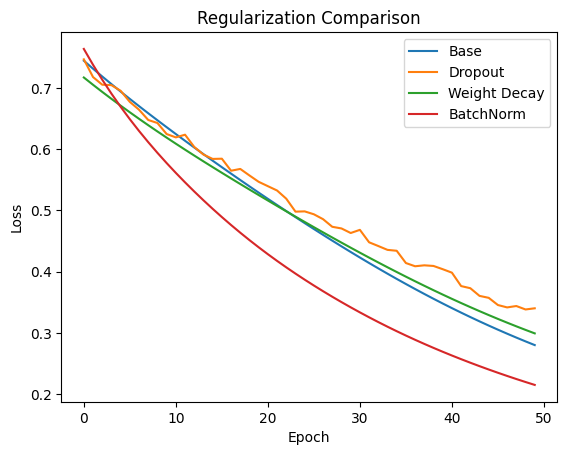

In [5]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(loss_history_base, label="Base")
plt.plot(loss_history_dropout, label="Dropout")
plt.plot(loss_history_wd, label="Weight Decay")
plt.plot(loss_history_bn, label="BatchNorm")

plt.legend()
plt.title("Regularization Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()